In [21]:
from torchvision.io.image import decode_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights, fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

In [43]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1;
model = fasterrcnn_resnet50_fpn_v2(weights=weights,box_score_thresh=0.9).to(DEVICE)

# weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1;
# model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights,box_score_thresh=0.8).to(DEVICE)

_ = model.eval()

In [44]:
img = decode_image("../imagenes/object_detection/car2.png")
if img.shape[0] == 4:
    img = img[:3, :, :]

In [45]:
transform = transforms.Compose([
    # transforms.Resize((1536, 1536)),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_tensor = transform(img)

img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

In [46]:
print(weights.meta["categories"])
class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}
labels = [weights.meta["categories"][i] for i in prediction["labels"]]

['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [47]:
prediction = model(img_tensor)[0]
print(prediction['boxes'])

box = draw_bounding_boxes(img, boxes=prediction["boxes"],
                          labels=labels,
                          colors="red",
                          width=4, font_size=30)

tensor([[129.3652, 383.2774, 202.4505, 439.0125],
        [343.0814, 414.2238, 412.7890, 464.2906]], device='cuda:0',
       grad_fn=<StackBackward0>)


/home/christian/.pyenv/versions/3.13.2/envs/percepcion-computacional-actividades/lib/python3.13/site-packages/torchvision/utils.py:233: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


In [48]:
# binary_mask = (predicted_mask > 0.90).float()

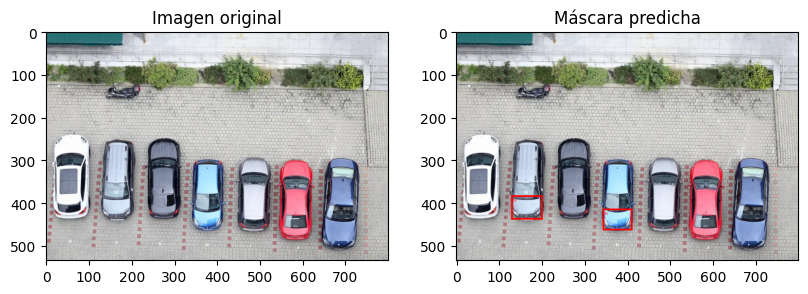

In [49]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.title("Imagen original")
plt.imshow(img.permute(1, 2, 0).cpu().numpy())
# plt.subplot(1,3,2)
# plt.title(f"Máscara segmentada")
# plt.imshow(binary_mask, cmap='gray')
plt.subplot(1,3,2)
plt.title(f"Máscara predicha")
plt.imshow(box.detach().permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.show()

In [9]:
weights.meta["categories"]

['__background__',
 'aeroplane',
 'bicycle',
 'bird',
 'boat',
 'bottle',
 'bus',
 'car',
 'cat',
 'chair',
 'cow',
 'diningtable',
 'dog',
 'horse',
 'motorbike',
 'person',
 'pottedplant',
 'sheep',
 'sofa',
 'train',
 'tvmonitor']

In [8]:
torch.cuda.empty_cache()